In [86]:
import pandas as pd
import matplotlib.pyplot as plt

In [50]:
df = pd.read_csv(r"data\Daily_Minimum_Temperatures_(Melbourne).csv")
df.head()

,Date,"Daily minimum temperatures in Melbourne, Australia, 1981-1990"
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [51]:
df.dtypes

Date                                                             object
Daily minimum temperatures in Melbourne, Australia, 1981-1990    object
dtype: object

In [52]:
df['Date'] = pd.to_datetime(df["Date"])

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column                                                         Non-Null Count  Dtype         
---  ------                                                         --------------  -----         
 0   Date                                                           3650 non-null   datetime64[ns]
 1   Daily minimum temperatures in Melbourne, Australia, 1981-1990  3650 non-null   object        
dtypes: datetime64[ns](1), object(1)
memory usage: 57.2+ KB


In [54]:
df.set_index("Date", inplace = True)

In [55]:
df = df.rename(columns = {"Daily minimum temperatures in Melbourne, Australia, 1981-1990": "Temperature"})

In [56]:
df.head()

,Temperature
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


In [57]:
df.index.is_monotonic_increasing #True

True

In [58]:
pd.date_range(start = df.index.min(), end = df.index.max()).difference(df.index)

DatetimeIndex(['1984-12-31', '1988-12-31'], dtype='datetime64[ns]', freq=None)

In [59]:
df.loc['1984-12-28':'1985-01-02']

,Temperature
Date,
1984-12-28,12.6
1984-12-29,16.0
1984-12-30,16.4
1985-01-01,13.3
1985-01-02,15.2


In [60]:
df.loc['1988-12-28':'1989-01-02']

,Temperature
Date,
1988-12-28,12.9
1988-12-29,14.8
1988-12-30,14.1
1989-01-01,14.3
1989-01-02,17.4


In [61]:
full_range = pd.date_range(start = df.index.min(), end = df.index.max())
df = df.reindex(full_range)

In [62]:
pd.date_range(start = df.index.min(), end = df.index.max()).difference(df.index)

DatetimeIndex([], dtype='datetime64[ns]', freq='D')

In [63]:
df.isnull().sum()

Temperature    2
dtype: int64

In [65]:
df.loc[['1982-07-20', '1982-07-21', '1984-07-14']]

,Temperature
1982-07-20,?0.2
1982-07-21,?0.8
1984-07-14,?0.1


In [70]:
df["Temperature"] = df["Temperature"].str.replace("?", "-")

In [71]:
df.loc[['1982-07-20', '1982-07-21', '1984-07-14']]

,Temperature
1982-07-20,-0.2
1982-07-21,-0.8
1984-07-14,-0.1


In [72]:
df["Temperature"] = pd.to_numeric(df["Temperature"])

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3652 entries, 1981-01-01 to 1990-12-31
Freq: D
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  3650 non-null   float64
dtypes: float64(1)
memory usage: 186.1 KB


In [74]:
df['Temperature'] = df['Temperature'].interpolate(method='linear')
df.isna().sum()

Temperature    0
dtype: int64

In [76]:
df.loc['1984-12-29':'1985-01-02']

,Temperature
1984-12-29,16.00
1984-12-30,16.40
1984-12-31,14.85
1985-01-01,13.30
1985-01-02,15.20


In [77]:
df.loc['1988-12-29':'1989-01-02']

,Temperature
1988-12-29,14.8
1988-12-30,14.1
1988-12-31,14.2
1989-01-01,14.3
1989-01-02,17.4


In [79]:
monthly = df['Temperature'].resample('ME').mean()

In [80]:
monthly.shape

(120,)

In [81]:
monthly.head()

1981-01-31    17.712903
1981-02-28    17.678571
1981-03-31    13.500000
1981-04-30    12.356667
1981-05-31     9.490323
Freq: ME, Name: Temperature, dtype: float64

<Axes: title={'center': 'Monthly Average Minimum Temperature'}>

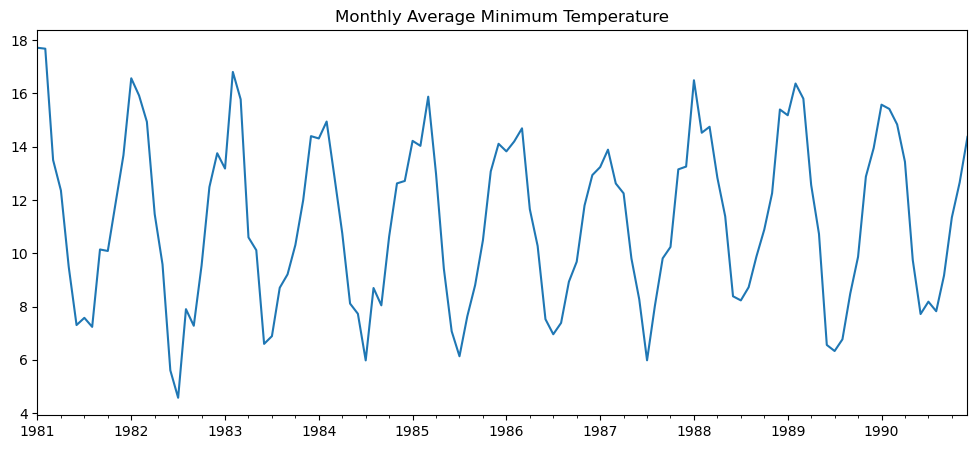

In [83]:
monthly.plot(figsize=(12,5), title="Monthly Average Minimum Temperature")

In [84]:
rolling_30 = df['Temperature'].rolling(window=30).mean()

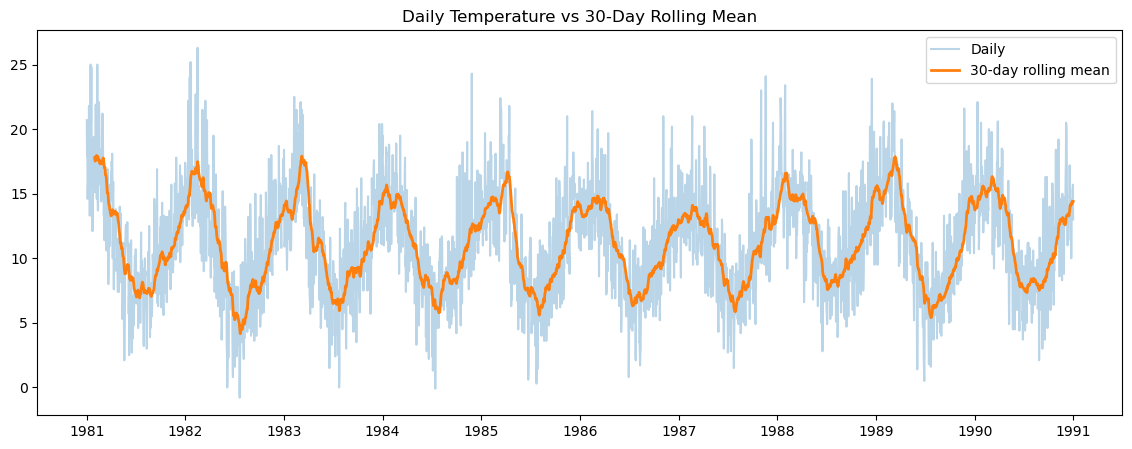

In [87]:
plt.figure(figsize=(14,5))
plt.plot(df['Temperature'], alpha=0.3, label='Daily')
plt.plot(rolling_30, label='30-day rolling mean', linewidth=2)
plt.legend()
plt.title("Daily Temperature vs 30-Day Rolling Mean")
plt.show()

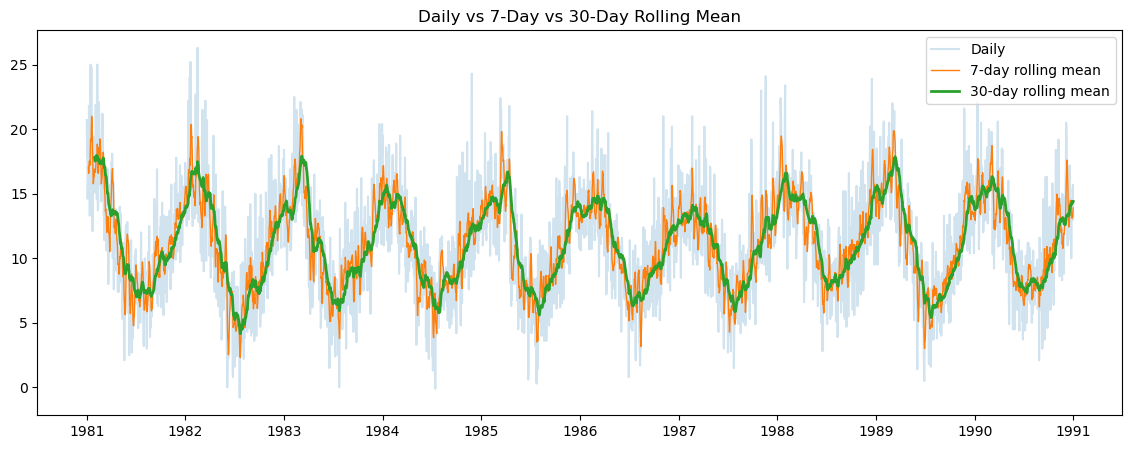

In [88]:
rolling_7 = df['Temperature'].rolling(window=7).mean()

plt.figure(figsize=(14,5))
plt.plot(df['Temperature'], alpha=0.2, label='Daily')
plt.plot(rolling_7, label='7-day rolling mean', linewidth=1)
plt.plot(rolling_30, label='30-day rolling mean', linewidth=2)
plt.legend()
plt.title("Daily vs 7-Day vs 30-Day Rolling Mean")
plt.show()